# 使用预训练的模型 (PyTorch)

Install the Transformers, Datasets, and Evaluate libraries to run this notebook.

In [ ]:
!pip install datasets evaluate transformers[sentencepiece]

假设我们正在寻找一种可以执行掩码填充（mask filling 又称完形填空）的 French-based（法语）模型。

我们选择 **camembert-base checkpoint** 来尝试一下。我们需要做的仅仅是 **输入 camembert-base 标签！** 正如你在前几章中学习的，我们可以使用 `pipeline()` 功能：

In [ ]:
from transformers import pipeline

camembert_fill_mask = pipeline("fill-mask", model="camembert-base")
results = camembert_fill_mask("Le camembert est <mask> :)")

[
  {'sequence': 'Le camembert est délicieux :)', 'score': 0.49091005325317383, 'token': 7200, 'token_str': 'délicieux'}, 
  {'sequence': 'Le camembert est excellent :)', 'score': 0.1055697426199913, 'token': 2183, 'token_str': 'excellent'}, 
  {'sequence': 'Le camembert est succulent :)', 'score': 0.03453313186764717, 'token': 26202, 'token_str': 'succulent'}, 
  {'sequence': 'Le camembert est meilleur :)', 'score': 0.0330314114689827, 'token': 528, 'token_str': 'meilleur'}, 
  {'sequence': 'Le camembert est parfait :)', 'score': 0.03007650189101696, 'token': 1654, 'token_str': 'parfait'}
]

你唯一需要注意的是所选 **checkpoint 是否适合它将用于的任务**。例如，这里我们正在将 camembert-base checkpoint 加载在 fill-mask 管道，这完全没问题。但是如果我们在 text-classification 管道中加载该 checkpoint 结果没有任何意义，因为 camembert-base 不适合这个任务！

我们建议使用 Hugging Face Hub 中的**任务选择器**来选择合适的 checkpoint 。

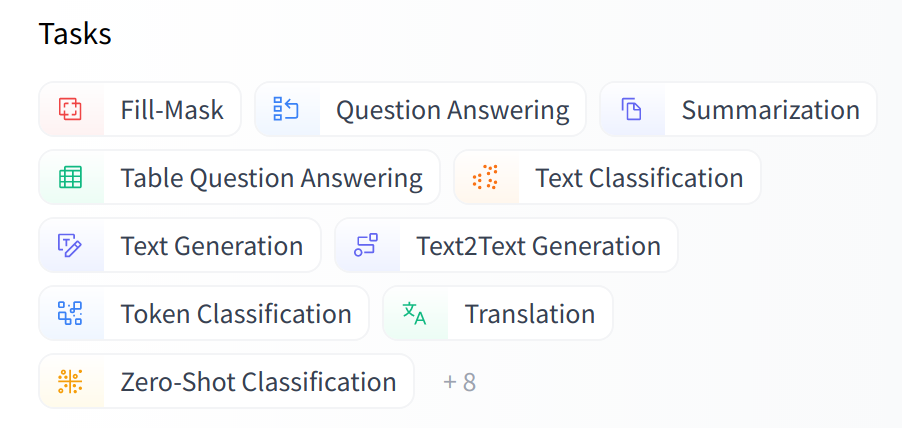

## pipeline 直接调用 vs 手动实例化模型+Tokenizer

### 方式1：高层封装 `pipeline()`（最简）
```python
from transformers import pipeline
camembert_fill_mask = pipeline("fill-mask", model="camembert-base")
results = camembert_fill_mask("Le camembert est <mask> :)")
```

### 方式2：手动架构类 / Auto 类实例化（底层原生）
1. 固定架构写法（只能用CamemBERT系列）
```python
from transformers import CamembertTokenizer, CamembertForMaskedLM
tokenizer = CamembertTokenizer.from_pretrained("camembert-base")
model = CamembertForMaskedLM.from_pretrained("camembert-base")
```
2. 通用Auto类（兼容任意同任务模型，推荐）
```python
from transformers import AutoTokenizer, AutoModelForMaskedLM
tokenizer = AutoTokenizer.from_pretrained("camembert-base")
model = AutoModelForMaskedLM.from_pretrained("camembert-base")
```


### 1. 封装层级不同
#### pipeline：高层一站式封装
自动完成全套流程，内部替你做：
1. 自动匹配对应 Tokenizer；
2. 加载对应任务的模型头（`ForMaskedLM`/`ForCausalLM`等）；
3. 自动文本编码、模型前向推理、logits→softmax、结果解码、排序输出；
4. 内置批量、设备自动迁移（CPU/GPU）、采样参数等默认逻辑。
你只需要输入原始字符串，直接拿到可读结果（文档里带score、sequence的字典列表）。

#### 手动实例化（Auto/固定架构类）：底层裸模型
只加载**分词器 + 权重网络**，中间所有步骤必须自己手写：
- 手动调用 `tokenizer()` 编码文本；
- 手动把张量移到GPU；
- 手动 `model()` 前向传播，拿到原始 logits；
- 手动 softmax、取topk、转回token字符串、组装结果；
自由度极高，但代码量大。

### 2. 通用性 & 切换成本
1. **pipeline**
*  只需修改两个参数：任务名、模型名，其余代码不动。
例：`pipeline("fill-mask", model="roberta-base")` 直接切换英文RoBERTa，无需改导入。

2. **固定架构类**（CamembertTokenizer/CamembertForMaskedLM）
*  强绑定模型架构，换RoBERTa就要全部替换导入类：
`RobertaTokenizer / RobertaForMaskedLM`，切换模型成本高。

3. **Auto类**（AutoTokenizer/AutoModelForXXX）
*  折中方案：不用改导入，仅修改模型名即可切换不同架构，比固定架构灵活，但仍要自己处理推理逻辑。

### 3. 使用场景差异
#### 选 pipeline 的场景
- 快速验证、demo、简单推理、不关心底层计算；
- 只想几行代码拿到可直接阅读的结构化输出；
- 新手快速上手，不想处理tensor、logits、softmax。

#### 手动实例化（Auto/架构类）的场景
1. 需要自定义推理逻辑：修改logits、调整temperature、自定义过滤token；
2. 模型微调、训练流程（训练必须裸model+tokenizer，pipeline不支持训练）；
3. 复杂业务控制：自定义batch、梯度控制、多阶段特征提取；
4. 读取中间隐层输出（hidden states）做文本表征、向量检索；
5. 精细化性能优化：手动控制device、混合精度、分布式推理。

### 4. 灵活性与可控性
- pipeline：黑盒，内部logits、采样、解码逻辑封装，难以自定义修改；
- 手动实例化：完全透明，能干预每一步张量运算，可对模型输出的原始logits任意处理。

你还可以直接**使用模型架构实例化 checkpoint**：

In [ ]:
from transformers import CamembertTokenizer, CamembertForMaskedLM

tokenizer = CamembertTokenizer.from_pretrained("camembert-base")
model = CamembertForMaskedLM.from_pretrained("camembert-base")

然而，我们建议使用 Auto* 类 ，因为 Auto* 类在设计时不依赖模型架构。前面的代码示例将只能在 CamemBERT 架构中加载可用的 checkpoint，但使用 Auto* 类使切换不同的 checkpoint 变得简单：

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

tokenizer = AutoTokenizer.from_pretrained("camembert-base")
model = AutoModelForMaskedLM.from_pretrained("camembert-base")